# `no2_frac_valid_radius` P(detect) curve (reviewer response)

Standalone figure to support the App. E argument that the **scene-level**
cloud filter ("$\geq$50% of pixels within 50 km of the plant pass qa$>$0.75")
from §2.2 absorbs much of the cloud signal upstream.

Three panels (mirrors `9_cloud_fraction_pod.ipynb`):
- (a) Distribution of `no2_frac_valid_radius` after qa$>$0.75 + 50% filters
- (b) U.S. P(detect) vs `no2_frac_valid_radius` quantile bin
- (c) Global P(detect) vs `no2_frac_valid_radius` quantile bin

Same paper-revision filters: 171-plant strict for U.S., interference-filter for global.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

sys.path.insert(0, '/net/fs06/d3/rzhuang/TROPOMI/code')
from shared.interference import (identify_interference_us_by_year,
                                 identify_interference_world)

plt.rcdefaults()
plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300,
    'font.size': 11, 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#2E3440', 'text.color': '#2E3440',
})

nimbus_path = None
for _p in fm.findSystemFonts():
    _pl = _p.lower()
    if ('nimbusroman' in _pl or 'nimbus_roman' in _pl) \
            and 'bold' not in _pl and 'italic' not in _pl and 'oblique' not in _pl:
        nimbus_path = _p; break
if nimbus_path:
    fm.fontManager.addfont(nimbus_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=nimbus_path).get_name()
    print('Registered:', plt.rcParams['font.family'])

colors = {'us': '#FF6B6B', 'global': '#4ECDC4', 'text': '#2E3440'}

US_CSV    = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
WORLD_CSV = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/updated_tropomi_emissions_full_variables_with_fuel_100mlabel.csv'
US_FAC    = '/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'
US_ANN    = '/net/fs06/d3/rzhuang/TROPOMI/data/us/annual-emissions-facility-aggregation-2019-2024.csv'
WORLD_PL  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv'
CITY_CSV  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv'
OUT_DIR   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures'
os.makedirs(OUT_DIR, exist_ok=True)

FEAT = 'no2_frac_valid_radius'
N_BINS = 10

Registered: ['Nimbus Roman']


In [2]:
# ─── Load + apply paper filters ──────────────────────────────────────
print('Loading U.S. snapshots ...')
us = pd.read_csv(US_CSV).dropna()
us_pl = pd.read_csv(US_FAC).sort_values('NOx_Rank')
us_an = pd.read_csv(US_ANN)
city  = pd.read_csv(CITY_CSV)

US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]
top500   = us_pl.head(500)['Facility_ID'].tolist()
emis_top = us_an[us_an['Facility ID'].isin(top500)]
present  = emis_top[emis_top['Year'].isin(US_YEARS)].groupby('Facility ID')['Year'].nunique()
complete_6y = set(present[present == len(US_YEARS)].index)
interf_us = identify_interference_us_by_year(
    us_pl[us_pl['Facility_ID'].isin(complete_6y)],
    emis_top[emis_top['Facility ID'].isin(complete_6y)],
    city, plant_subset_ids=list(complete_6y))
ever = set().union(*[set(v) for v in interf_us.values()])
us_kept = complete_6y - ever
df_us = us[us['location'].isin(us_kept)].copy()
print(f'U.S.: {len(df_us):,} obs across {len(us_kept)} plants (171 recipe)')

print('\nLoading global snapshots ...')
wl = pd.read_csv(WORLD_CSV).dropna(subset=['plume_label','location',FEAT])
wl_pl = pd.read_csv(WORLD_PL)
gl_ids = wl['location'].astype(str).str.strip().unique().tolist()
interf_w = identify_interference_world(wl_pl, city, plant_subset_ids=gl_ids)
df_gl = wl[~wl['location'].astype(str).str.strip().isin({str(x).strip() for x in interf_w})].copy()
print(f'Global: {len(df_gl):,} obs across {df_gl["location"].nunique()} plants')

# Sanity: §2.2 says the filter requires no2_frac_valid_radius >= 0.5,
# so distribution should be bounded below by 0.5.
print(f"\n{FEAT} range:")
print(f'  U.S.:   min={df_us[FEAT].min():.3f}, p1={df_us[FEAT].quantile(.01):.3f}, '
      f'p50={df_us[FEAT].median():.3f}, max={df_us[FEAT].max():.3f}')
print(f'  Global: min={df_gl[FEAT].min():.3f}, p1={df_gl[FEAT].quantile(.01):.3f}, '
      f'p50={df_gl[FEAT].median():.3f}, max={df_gl[FEAT].max():.3f}')

Loading U.S. snapshots ...
Identifying plants in interference zones by year...
Year 2019: 283 interfered / 460 plants
Year 2020: 283 interfered / 460 plants
Year 2021: 283 interfered / 460 plants
Year 2022: 283 interfered / 460 plants
Year 2023: 283 interfered / 460 plants
Year 2024: 283 interfered / 460 plants
U.S.: 189,713 obs across 171 plants (171 recipe)

Loading global snapshots ...
Identifying plants in interference zones (global)...


Checking interference: 100%|██████████| 6000/6000 [00:02<00:00, 2056.98it/s]


Found 4935 interfered / 6000 plants
Global: 161,118 obs across 1065 plants

no2_frac_valid_radius range:
  U.S.:   min=0.496, p1=0.666, p50=0.939, max=1.621
  Global: min=0.487, p1=0.610, p50=0.944, max=148.229


In [3]:
# ─── P(detect) by no2_frac_valid_radius quantile bin ─────────────────
def pod_curve(df, feat=FEAT, target='plume_label', n=N_BINS, clip=(0.01, 0.99)):
    """Bin centre = median of observed values in bin (not interval midpoint)."""
    s = pd.to_numeric(df[feat], errors='coerce')
    y = pd.to_numeric(df[target], errors='coerce').fillna(0).astype(int)
    m = s.notna()
    s, y = s[m], y[m]
    if clip:
        lo, hi = s.quantile(clip[0]), s.quantile(clip[1])
        m2 = (s >= lo) & (s <= hi)
        s, y = s[m2], y[m2]
    bins = pd.qcut(s, q=n, duplicates='drop')
    g_y = y.groupby(bins, observed=False)
    g_s = s.groupby(bins, observed=False)
    total, pos = g_y.count(), g_y.sum()
    pod   = pos / total.replace(0, np.nan)
    se    = np.sqrt(pod * (1 - pod) / total.replace(0, np.nan))
    centers = g_s.median()
    return pd.DataFrame({'center': centers.values, 'pod': pod.values,
                          'se': se.values, 'n': total.values})

p_us = pod_curve(df_us)
p_gl = pod_curve(df_gl)
print('U.S. POD curve:')
print(p_us.to_string(index=False))
print('\nGlobal POD curve:')
print(p_gl.to_string(index=False))

U.S. POD curve:
  center      pod       se     n
0.788826 0.290340 0.003329 18592
0.833713 0.313307 0.003402 18592
0.865830 0.362971 0.003527 18591
0.896591 0.347765 0.003493 18593
0.925799 0.333871 0.003459 18591
0.951392 0.345275 0.003487 18591
0.970874 0.370428 0.003542 18592
0.983001 0.397988 0.003590 18591
0.993775 0.348752 0.003495 18592
1.007983 0.298354 0.003356 18592

Global POD curve:
  center      pod       se     n
0.760871 0.285687 0.003595 15790
0.838751 0.360694 0.003822 15789
0.881308 0.428590 0.003938 15789
0.913246 0.434136 0.003944 15790
0.936349 0.419469 0.003927 15789
0.951335 0.453164 0.003962 15789
0.965599 0.453198 0.003962 15790
0.978965 0.413326 0.003919 15789
0.990583 0.381278 0.003865 15789
1.006118 0.319506 0.003711 15790


Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/no2_frac_valid_radius_pod.pdf
Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/no2_frac_valid_radius_pod.png


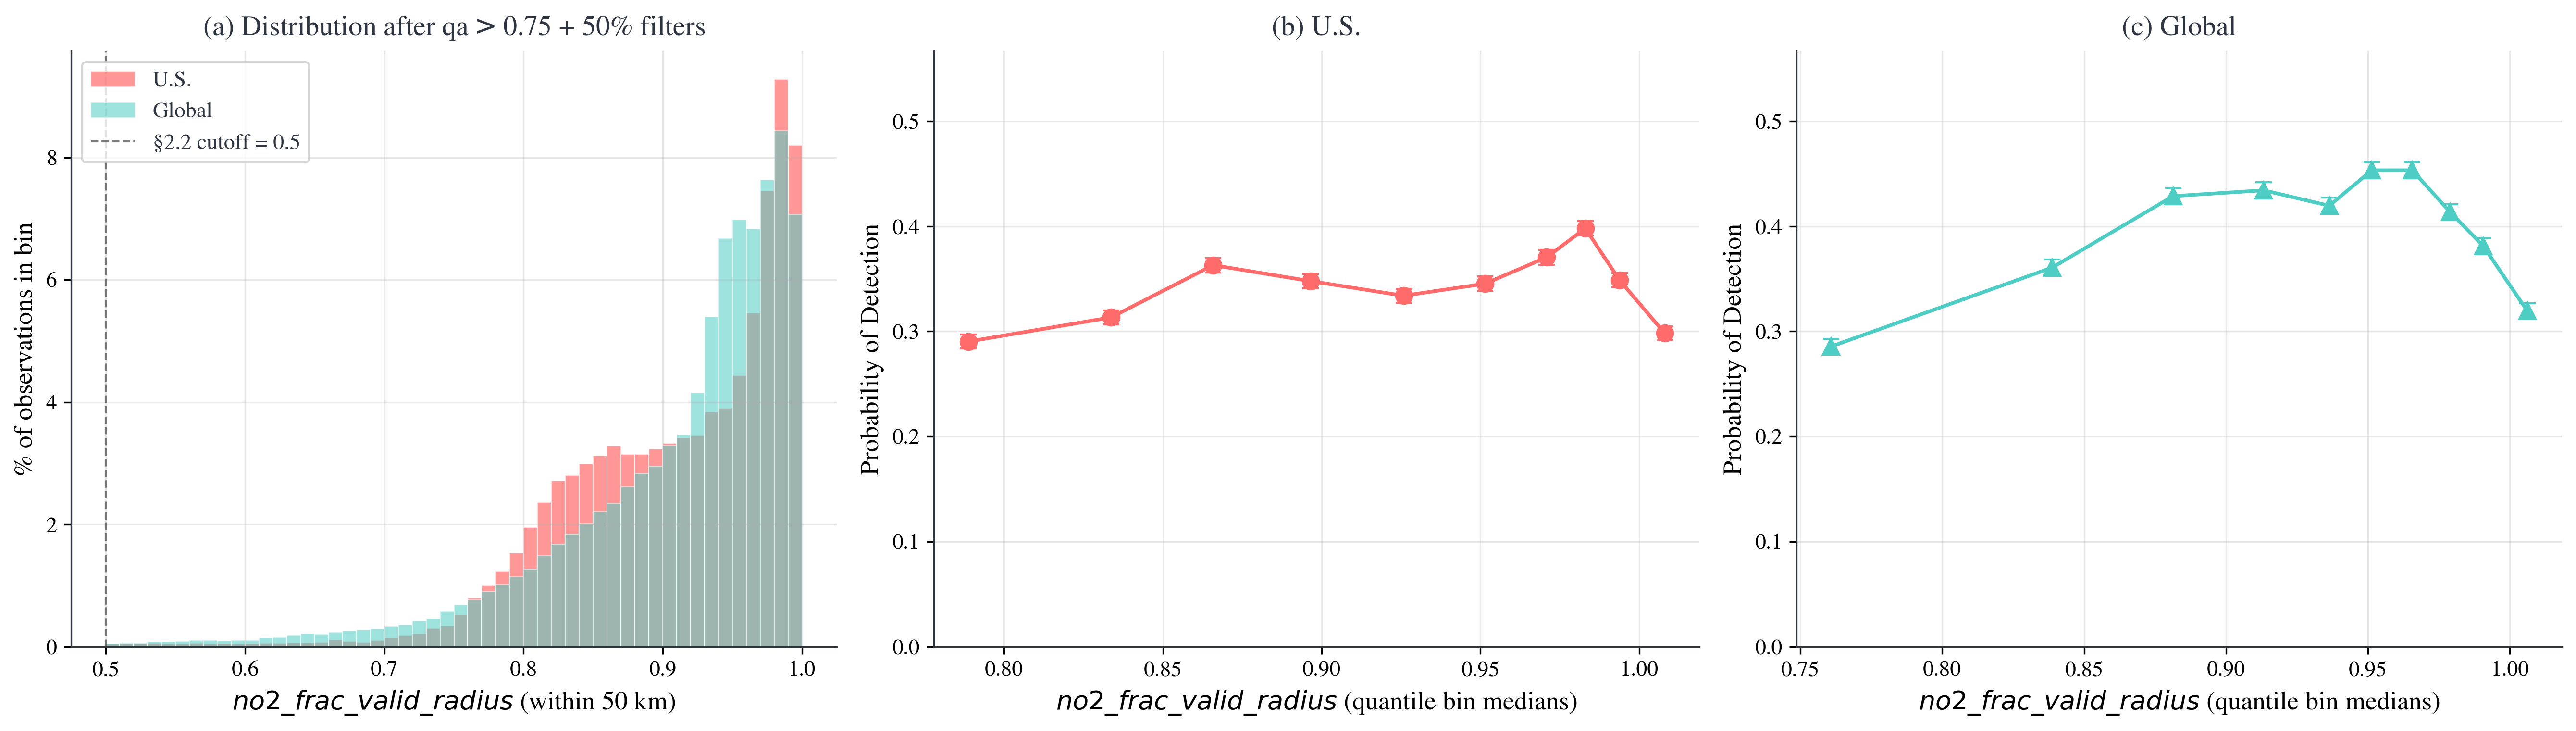

In [4]:
# ─── 3-panel figure: (a) distribution, (b) U.S. POD, (c) Global POD ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), facecolor='white')

# Panel a: % of observations per bin
ax = axes[0]
us_w = 100.0 / len(df_us) * np.ones(len(df_us))
gl_w = 100.0 / len(df_gl) * np.ones(len(df_gl))
# no2_frac_valid_radius is bounded above by 1 and below by ~0.5 (filter cutoff).
ax.hist(df_us[FEAT], bins=50, range=(0.5, 1.0), weights=us_w,
        alpha=0.7, color=colors['us'], label='U.S.',
        edgecolor='white', linewidth=0.5)
ax.hist(df_gl[FEAT], bins=50, range=(0.5, 1.0), weights=gl_w,
        alpha=0.55, color=colors['global'], label='Global',
        edgecolor='white', linewidth=0.5)
ax.axvline(0.50, ls='--', color='#444', lw=1, alpha=0.7, label='\u00a72.2 cutoff = 0.5')
ax.set_xlabel(r'$no2\_frac\_valid\_radius$ (within 50 km)',
              fontsize=13, fontweight='600')
ax.set_ylabel('% of observations in bin', fontsize=13, fontweight='600')
ax.set_title('(a) Distribution after qa$>$0.75 + 50% filters',
             fontsize=14, fontweight='bold', pad=8)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

# Panel b: U.S. POD
ax = axes[1]
ax.errorbar(p_us['center'], p_us['pod'], yerr=1.96 * p_us['se'],
            marker='o', ms=8, lw=1.8, color=colors['us'], capsize=4)
ax.set_xlabel(r'$no2\_frac\_valid\_radius$ (quantile bin medians)',
              fontsize=13, fontweight='600')
ax.set_ylabel('Probability of Detection', fontsize=13, fontweight='600')
ax.set_title('(b) U.S.', fontsize=14, fontweight='bold', pad=8)
ax.grid(True, alpha=0.3)
y_max = float(max(p_us['pod'].max(), p_gl['pod'].max())) * 1.25
ax.set_ylim(0, y_max)

# Panel c: Global POD
ax = axes[2]
ax.errorbar(p_gl['center'], p_gl['pod'], yerr=1.96 * p_gl['se'],
            marker='^', ms=8, lw=1.8, color=colors['global'], capsize=4)
ax.set_xlabel(r'$no2\_frac\_valid\_radius$ (quantile bin medians)',
              fontsize=13, fontweight='600')
ax.set_ylabel('Probability of Detection', fontsize=13, fontweight='600')
ax.set_title('(c) Global', fontsize=14, fontweight='bold', pad=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, y_max)

plt.tight_layout()
out_pdf = os.path.join(OUT_DIR, 'no2_frac_valid_radius_pod.pdf')
out_png = os.path.join(OUT_DIR, 'no2_frac_valid_radius_pod.png')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(out_png, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out_pdf}')
print(f'Saved: {out_png}')

p_us.to_csv(os.path.join(OUT_DIR, 'no2_frac_valid_radius_pod_us.csv'),    index=False)
p_gl.to_csv(os.path.join(OUT_DIR, 'no2_frac_valid_radius_pod_world.csv'), index=False)
plt.show()